# Carbon Emission — Decision Tree Training
### 15,563 rows | 9,480 Household + 6,083 Industrial | 29 columns
### Run each cell one by one in order

## CELL 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

print('All libraries loaded successfully')

All libraries loaded successfully


## CELL 2 — Load Merged Dataset

In [2]:
df = pd.read_csv(r'C:\Users\HP\Carbon_emission\merged_carbon_final.csv')

print('=== DATASET LOADED ===')
print(f'Total rows     : {len(df)}')
print(f'Total columns  : {len(df.columns)}')
print(f'Household rows : {(df["type"]==0).sum()}')
print(f'Industrial rows: {(df["type"]==1).sum()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'All numeric    : {all(df.dtypes != object)}')
print(f'\nColumns: {df.columns.tolist()}')
display(df.head(5))

=== DATASET LOADED ===
Total rows     : 15563
Total columns  : 29
Household rows : 9480
Industrial rows: 6083
Missing values : 0
All numeric    : True

Columns: ['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'monthly_grocery_bill', 'frequency_of_traveling_by_air', 'vehicle_monthly_distance_km', 'waste_bag_size', 'waste_bag_weekly_count', 'how_long_tv_pc_daily_hour', 'how_many_new_clothes_monthly', 'how_long_internet_daily_hour', 'energy_efficiency', 'recycling', 'cooking_with', 'co2', 'type', 'country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']


,body_type,sex,diet,how_often_shower,heating_energy_source,transport,vehicle_type,social_activity,monthly_grocery_bill,frequency_of_traveling_by_air,...,co2,type,country,year,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,other_industry_co2
0,3,1,2,1,1,2,5,2,230.0,1,...,2238.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,4,2,3,3,5,2,114.0,3,...,1892.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2,1,3,4,1,6,1,138.0,2,...,2595.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2,1,4,4,3,5,3,157.0,3,...,1074.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,1,4,1,1,1,1,2,266.0,4,...,4743.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## CELL 3 — Prepare Features (X) and Target (y)

In [3]:
# ── X: all columns except co2 ─────────────────────────────────────
X = df.drop(columns=['co2'])

# ── y_reg: exact CO2 value for regression tree ────────────────────
y_reg = df['co2'].copy()

# ── y_cls: LOW / MEDIUM / HIGH bands for classification tree ──────
# Household bands  (kg/year):  LOW <1500 | MEDIUM 1500-3500 | HIGH >3500
# Industrial bands (kg/year):  LOW <1e11 | MEDIUM 1e11-1e12 | HIGH >1e12
def assign_band(row):
    if row['type'] == 0:   # Household
        if   row['co2'] < 1500:  return 0  # LOW
        elif row['co2'] < 3500:  return 1  # MEDIUM
        else:                    return 2  # HIGH
    else:                  # Industrial
        if   row['co2'] < 1e11:  return 0  # LOW
        elif row['co2'] < 1e12:  return 1  # MEDIUM
        else:                    return 2  # HIGH

df['emission_band'] = df.apply(assign_band, axis=1)
y_cls = df['emission_band'].copy()

band_names = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

print('=== FEATURES AND TARGET PREPARED ===')
print(f'Feature matrix X : {X.shape}')
print(f'Features used    : {X.columns.tolist()}')
print(f'\nRegression target (y_reg):')
print(f'  Household  CO2 — min: {df[df["type"]==0]["co2"].min():.0f}  max: {df[df["type"]==0]["co2"].max():.0f} kg')
print(f'  Industrial CO2 — min: {df[df["type"]==1]["co2"].min():.2e}  max: {df[df["type"]==1]["co2"].max():.2e} kg')
print(f'\nClassification target (y_cls) band counts:')
print(y_cls.map(band_names).value_counts())

=== FEATURES AND TARGET PREPARED ===
Feature matrix X : (15563, 28)
Features used    : ['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'monthly_grocery_bill', 'frequency_of_traveling_by_air', 'vehicle_monthly_distance_km', 'waste_bag_size', 'waste_bag_weekly_count', 'how_long_tv_pc_daily_hour', 'how_many_new_clothes_monthly', 'how_long_internet_daily_hour', 'energy_efficiency', 'recycling', 'cooking_with', 'type', 'country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']

Regression target (y_reg):
  Household  CO2 — min: 705  max: 5366 kg
  Industrial CO2 — min: 4.00e+06  max: 3.86e+13 kg

Classification target (y_cls) band counts:
emission_band
MEDIUM    7363
LOW       6556
HIGH      1644
Name: count, dtype: int64


## CELL 4 — Train / Test Split (80% train | 20% test)

In [4]:
# Regression split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Classification split (same random_state so same rows)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

print('=== TRAIN / TEST SPLIT ===')
print(f'Total rows       : {len(df)}')
print(f'Training rows    : {len(X_train_r)}  ({len(X_train_r)/len(df)*100:.0f}%)')
print(f'Testing rows     : {len(X_test_r)}   ({len(X_test_r)/len(df)*100:.0f}%)')
print(f'Features         : {X.shape[1]}')
print(f'\nTraining band distribution:')
print(y_train_c.map(band_names).value_counts())
print(f'\nTesting band distribution:')
print(y_test_c.map(band_names).value_counts())

=== TRAIN / TEST SPLIT ===
Total rows       : 15563
Training rows    : 12450  (80%)
Testing rows     : 3113   (20%)
Features         : 28

Training band distribution:
emission_band
MEDIUM    5852
LOW       5275
HIGH      1323
Name: count, dtype: int64

Testing band distribution:
emission_band
MEDIUM    1511
LOW       1281
HIGH       321
Name: count, dtype: int64


## CELL 5 — Train Decision Tree Regressor (predicts exact CO2 kg)

In [5]:
reg_tree = DecisionTreeRegressor(
    max_depth        = 8,   # max levels the tree grows
    min_samples_split= 10,  # min rows needed to make a split
    min_samples_leaf = 5,   # min rows in each leaf node
    random_state     = 42
)

reg_tree.fit(X_train_r, y_train_r)

print('=== REGRESSION TREE TRAINED ===')
print(f'Tree depth       : {reg_tree.get_depth()}')
print(f'Number of leaves : {reg_tree.get_n_leaves()}')
print(f'Features used    : {reg_tree.n_features_in_}')

=== REGRESSION TREE TRAINED ===
Tree depth       : 8
Number of leaves : 75
Features used    : 28


## CELL 6 — Train Decision Tree Classifier (predicts LOW / MEDIUM / HIGH)

In [6]:
cls_tree = DecisionTreeClassifier(
    max_depth        = 8,
    min_samples_split= 10,
    min_samples_leaf = 5,
    random_state     = 42
)

cls_tree.fit(X_train_c, y_train_c)

print('=== CLASSIFICATION TREE TRAINED ===')
print(f'Tree depth       : {cls_tree.get_depth()}')
print(f'Number of leaves : {cls_tree.get_n_leaves()}')
print(f'Features used    : {cls_tree.n_features_in_}')

=== CLASSIFICATION TREE TRAINED ===
Tree depth       : 8
Number of leaves : 131
Features used    : 28


## CELL 7 — Regression Accuracy: R², MAE, RMSE, MAPE

   REGRESSION ACCURACY METRICS
  R² Score   : 0.9868  → model explains 98.7% of CO2 variation
  MAE        : 34315247111.77 kg  → avg error per prediction
  RMSE       : 232827027959.99 kg  → large errors penalised more
  MAPE       : 522.70%  → avg % error
  CV R²      : 0.6277 ± 0.0224  → consistent across 5 folds
  Result — EXCELLENT accuracy


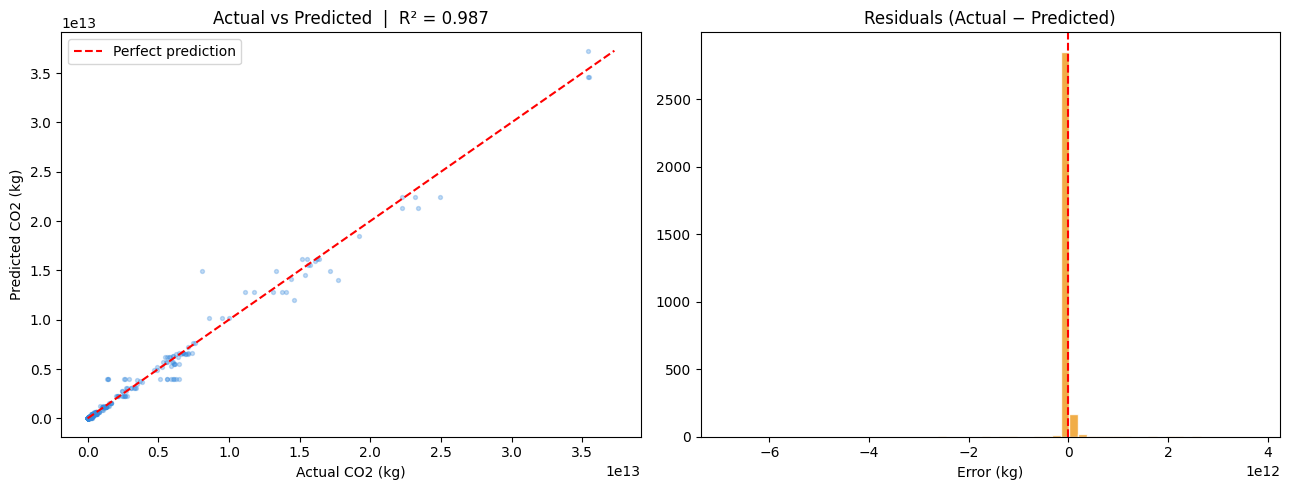

Chart saved


In [7]:
y_pred_r = reg_tree.predict(X_test_r)

r2   = r2_score(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mape = np.mean(np.abs((y_test_r - y_pred_r) / (y_test_r + 1e-9))) * 100

# 5-fold cross validation
cv_r2 = cross_val_score(reg_tree, X, y_reg, cv=5, scoring='r2')

print('=' * 50)
print('   REGRESSION ACCURACY METRICS')
print('=' * 50)
print(f'  R² Score   : {r2:.4f}  → model explains {r2*100:.1f}% of CO2 variation')
print(f'  MAE        : {mae:.2f} kg  → avg error per prediction')
print(f'  RMSE       : {rmse:.2f} kg  → large errors penalised more')
print(f'  MAPE       : {mape:.2f}%  → avg % error')
print(f'  CV R²      : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  → consistent across 5 folds')
print('=' * 50)
if r2 >= 0.85: print('  Result — EXCELLENT accuracy')
elif r2 >= 0.70: print('  Result — GOOD accuracy')
elif r2 >= 0.50: print('  Result — ACCEPTABLE accuracy')
else: print('  Result — needs improvement')

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_r, y_pred_r, alpha=0.3, s=8, color='#378ADD')
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual CO2 (kg)')
axes[0].set_ylabel('Predicted CO2 (kg)')
axes[0].set_title(f'Actual vs Predicted  |  R² = {r2:.3f}')
axes[0].legend()

residuals = y_test_r.values - y_pred_r
axes[1].hist(residuals, bins=60, color='#EF9F27', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_xlabel('Error (kg)')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Carbon_emission\regression_accuracy.png', dpi=120)
plt.show()
print('Chart saved')

## CELL 8 — Classification Accuracy: Accuracy %, F1 Score, Report

In [8]:
y_pred_c = cls_tree.predict(X_test_c)

acc    = accuracy_score(y_test_c, y_pred_c)
f1_w   = f1_score(y_test_c, y_pred_c, average='weighted')
f1_mac = f1_score(y_test_c, y_pred_c, average='macro')
f1_per = f1_score(y_test_c, y_pred_c, average=None)

# 5-fold cross validation for classification
cv_acc = cross_val_score(cls_tree, X, y_cls, cv=5, scoring='accuracy')

print('=' * 50)
print('   CLASSIFICATION ACCURACY METRICS')
print('=' * 50)
print(f'  Accuracy         : {acc*100:.2f}%')
print(f'  F1 (weighted)    : {f1_w:.4f}')
print(f'  F1 (macro)       : {f1_mac:.4f}')
print(f'  F1 — LOW band    : {f1_per[0]:.4f}')
print(f'  F1 — MEDIUM band : {f1_per[1]:.4f}')
print(f'  F1 — HIGH band   : {f1_per[2]:.4f}')
print(f'  CV Accuracy      : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print('=' * 50)
print(f'\nCorrectly classified: {int(acc*len(y_test_c))} / {len(y_test_c)} rows')
print('\n--- Full Classification Report ---')
print(classification_report(y_test_c, y_pred_c, target_names=['LOW','MEDIUM','HIGH']))

   CLASSIFICATION ACCURACY METRICS
  Accuracy         : 87.73%
  F1 (weighted)    : 0.8774
  F1 (macro)       : 0.8664
  F1 — LOW band    : 0.8879
  F1 — MEDIUM band : 0.8779
  F1 — HIGH band   : 0.8333
  CV Accuracy      : 75.54% ± 9.75%

Correctly classified: 2731 / 3113 rows

--- Full Classification Report ---
              precision    recall  f1-score   support

         LOW       0.93      0.85      0.89      1281
      MEDIUM       0.85      0.91      0.88      1511
        HIGH       0.84      0.83      0.83       321

    accuracy                           0.88      3113
   macro avg       0.87      0.86      0.87      3113
weighted avg       0.88      0.88      0.88      3113



## CELL 9 — Confusion Matrix

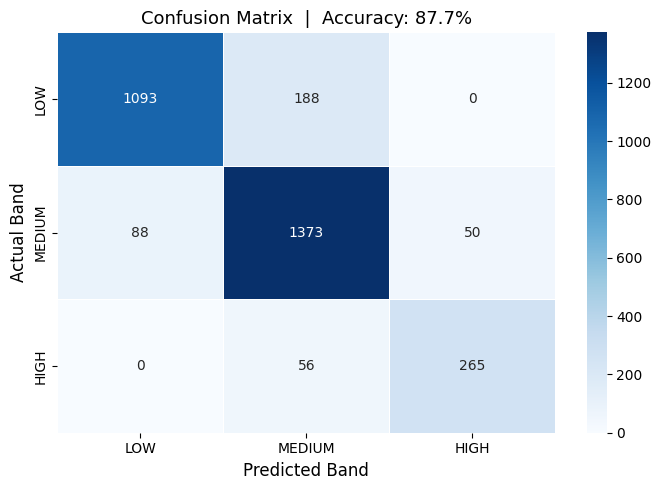

How to read:
  Diagonal (correct predictions) : 2731 rows
  Off-diagonal (wrong)           : 382 rows
  Correct %                      : 87.7%


In [9]:
cm = confusion_matrix(y_test_c, y_pred_c)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['LOW','MEDIUM','HIGH'],
    yticklabels=['LOW','MEDIUM','HIGH'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Band', fontsize=12)
ax.set_ylabel('Actual Band', fontsize=12)
ax.set_title(f'Confusion Matrix  |  Accuracy: {acc*100:.1f}%', fontsize=13)

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Carbon_emission\confusion_matrix.png', dpi=120)
plt.show()

print('How to read:')
print(f'  Diagonal (correct predictions) : {cm.diagonal().sum()} rows')
print(f'  Off-diagonal (wrong)           : {cm.sum() - cm.diagonal().sum()} rows')
print(f'  Correct %                      : {cm.diagonal().sum()/cm.sum()*100:.1f}%')

## CELL 10 — Feature Importance

=== FEATURE IMPORTANCE — What tree learned matters most ===
  oil_co2                             0.7378  █████████████████████████████████████████████████████████████████████████
  country                             0.1511  ███████████████
  flaring_co2                         0.0737  ███████
  cement_co2                          0.0148  █
  coal_co2                            0.0127  █
  year                                0.0069  
  other_industry_co2                  0.0021  
  gas_co2                             0.0010  
  how_often_shower                    0.0000  
  vehicle_monthly_distance_km         0.0000  
  frequency_of_traveling_by_air       0.0000  
  vehicle_type                        0.0000  
  sex                                 0.0000  
  waste_bag_size                      0.0000  
  transport                           0.0000  
  monthly_grocery_bill                0.0000  
  heating_energy_source               0.0000  
  diet                                0.0000

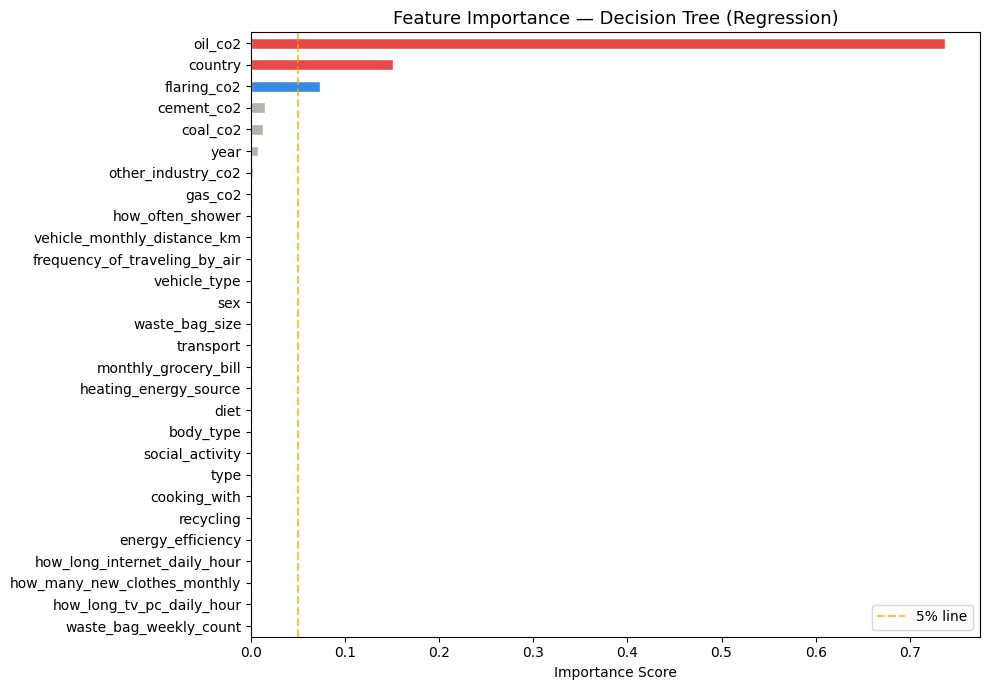

Chart saved


In [10]:
importance = pd.Series(
    reg_tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print('=== FEATURE IMPORTANCE — What tree learned matters most ===')
for feat, score in importance.items():
    bar = '█' * int(score * 100)
    print(f'  {feat:<35} {score:.4f}  {bar}')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E24B4A' if v > 0.1 else '#378ADD' if v > 0.03 else '#B4B2A9'
          for v in importance.values]
importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Decision Tree (Regression)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.axvline(0.05, color='orange', linestyle='--', alpha=0.7, label='5% line')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Carbon_emission\feature_importance.png', dpi=120)
plt.show()
print('Chart saved')

## CELL 11 — Decision Tree Structure (visual)

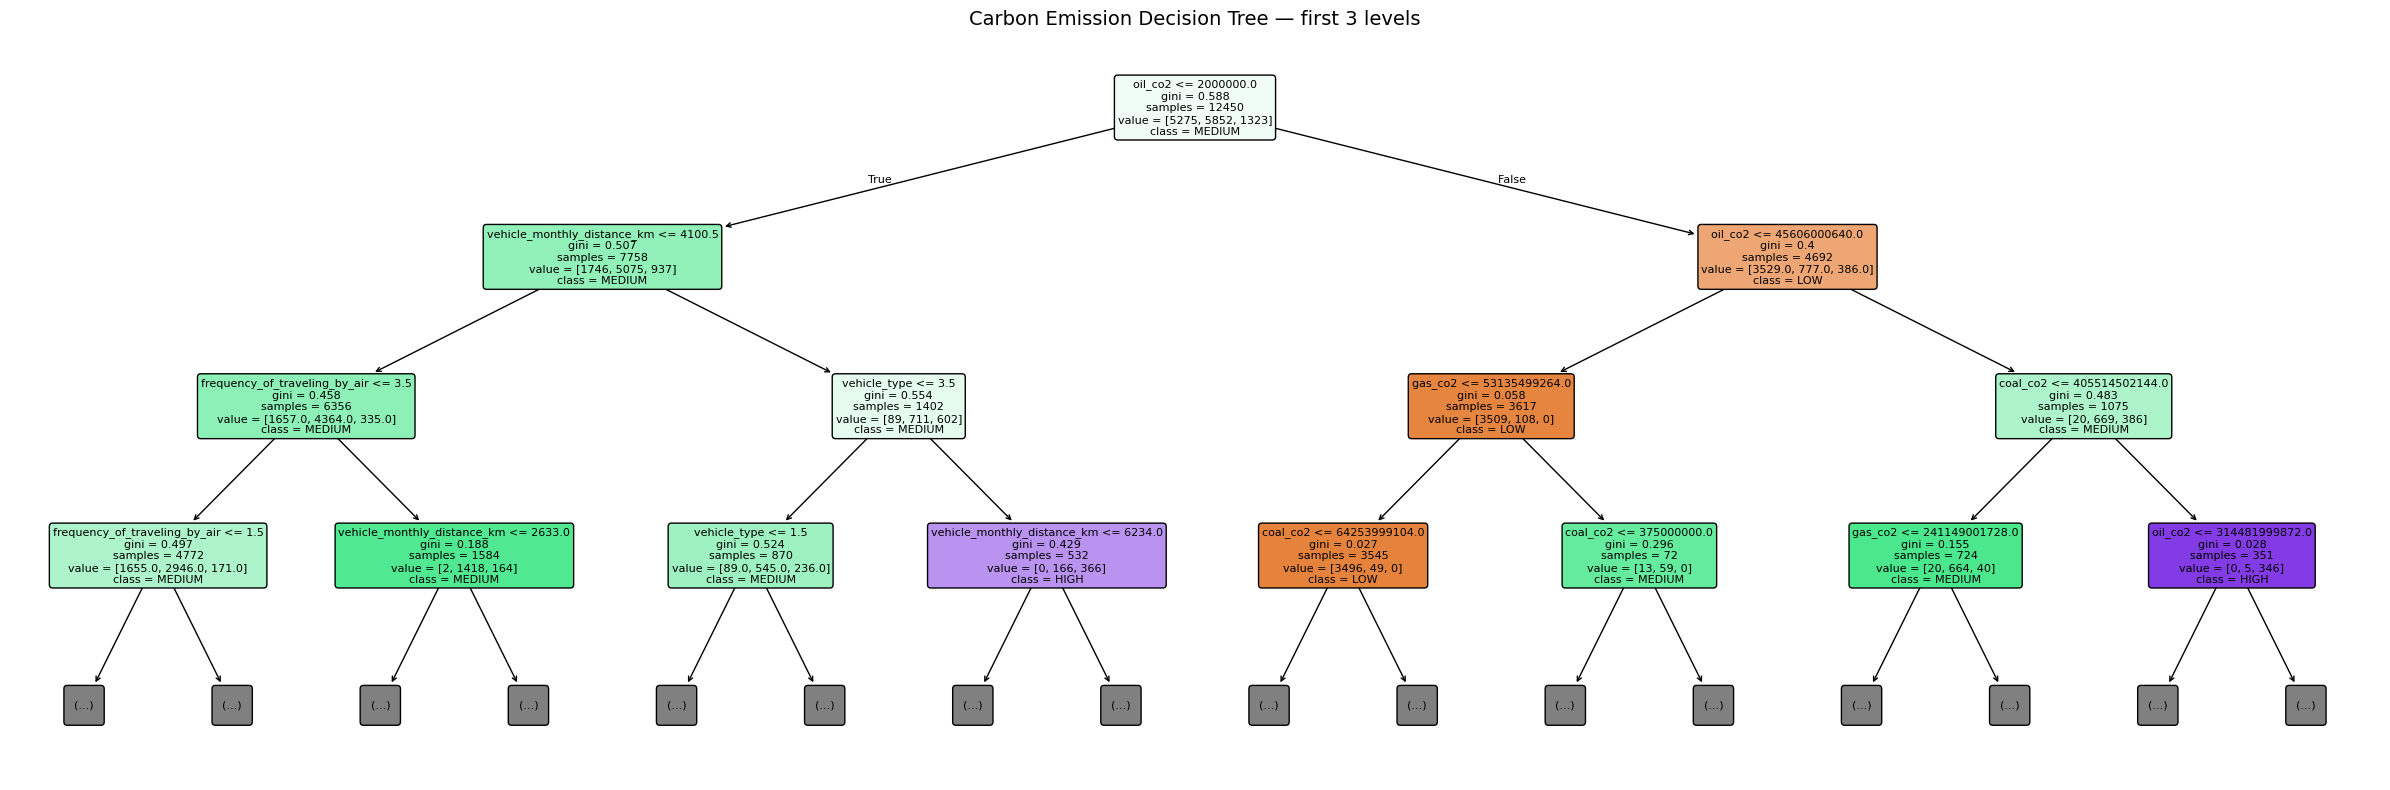

Tree structure saved


In [11]:
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    cls_tree,
    max_depth       = 3,
    feature_names   = X.columns.tolist(),
    class_names     = ['LOW','MEDIUM','HIGH'],
    filled          = True,
    rounded         = True,
    fontsize        = 8,
    ax              = ax
)
ax.set_title('Carbon Emission Decision Tree — first 3 levels', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Carbon_emission\decision_tree_structure.png',
            dpi=100, bbox_inches='tight')
plt.show()
print('Tree structure saved')

## CELL 12 — Household vs Industrial Separate Accuracy

In [12]:
# Split test set into household and industrial rows
X_test_all = X_test_r.copy()
X_test_all['actual']    = y_test_r.values
X_test_all['predicted'] = y_pred_r

H_test = X_test_all[X_test_all['type'] == 0]
I_test = X_test_all[X_test_all['type'] == 1]

def metrics(actual, predicted, label):
    r2   = r2_score(actual, predicted)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f'--- {label} ---')
    print(f'  Rows : {len(actual)}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:.2f} kg')
    print(f'  RMSE : {rmse:.2f} kg')

print('=== SEPARATE ACCURACY BY TYPE ===')
if len(H_test) > 0:
    metrics(H_test['actual'], H_test['predicted'], 'HOUSEHOLD')
if len(I_test) > 0:
    metrics(I_test['actual'], I_test['predicted'], 'INDUSTRIAL')
print('\nThis shows how well the single tree handles each type separately.')

=== SEPARATE ACCURACY BY TYPE ===
--- HOUSEHOLD ---
  Rows : 1924
  R²   : 0.6200
  MAE  : 424.79 kg
  RMSE : 553.04 kg
--- INDUSTRIAL ---
  Rows : 1189
  R²   : 0.9862
  MAE  : 89843030648.98 kg
  RMSE : 376731580378.58 kg

This shows how well the single tree handles each type separately.


## CELL 13 — Complete Accuracy Summary

In [13]:
print('=' * 60)
print('   COMPLETE MODEL ACCURACY SUMMARY')
print('=' * 60)
print(f'  Dataset          : 15,563 rows (9480 H + 6083 I)')
print(f'  Features         : {X.shape[1]} columns')
print(f'  Train/Test split : 80% / 20%')
print()
print('  REGRESSION TREE (predicts exact CO2 kg)')
print(f'    R² Score       : {r2:.4f}')
print(f'    MAE            : {mae:.2f} kg')
print(f'    RMSE           : {rmse:.2f} kg')
print(f'    MAPE           : {mape:.2f}%')
print(f'    Cross-Val R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print()
print('  CLASSIFICATION TREE (predicts LOW/MEDIUM/HIGH)')
print(f'    Accuracy       : {acc*100:.2f}%')
print(f'    F1 Weighted    : {f1_w:.4f}')
print(f'    F1 Macro       : {f1_mac:.4f}')
print(f'    F1 LOW         : {f1_per[0]:.4f}')
print(f'    F1 MEDIUM      : {f1_per[1]:.4f}')
print(f'    F1 HIGH        : {f1_per[2]:.4f}')
print(f'    Cross-Val Acc  : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print('=' * 60)

   COMPLETE MODEL ACCURACY SUMMARY
  Dataset          : 15,563 rows (9480 H + 6083 I)
  Features         : 28 columns
  Train/Test split : 80% / 20%

  REGRESSION TREE (predicts exact CO2 kg)
    R² Score       : 0.9868
    MAE            : 34315247111.77 kg
    RMSE           : 232827027959.99 kg
    MAPE           : 522.70%
    Cross-Val R²   : 0.6277 ± 0.0224

  CLASSIFICATION TREE (predicts LOW/MEDIUM/HIGH)
    Accuracy       : 87.73%
    F1 Weighted    : 0.8774
    F1 Macro       : 0.8664
    F1 LOW         : 0.8879
    F1 MEDIUM      : 0.8779
    F1 HIGH        : 0.8333
    Cross-Val Acc  : 75.54% ± 9.75%


## CELL 14 — Save Both Trained Models

In [14]:
joblib.dump(reg_tree, r'C:\Users\HP\Carbon_emission\model_regression.pkl')
joblib.dump(cls_tree, r'C:\Users\HP\Carbon_emission\model_classification.pkl')
joblib.dump(X.columns.tolist(), r'C:\Users\HP\Carbon_emission\feature_names.pkl')

print('Models saved:')
print('  model_regression.pkl     — predicts exact CO2 kg')
print('  model_classification.pkl — predicts LOW/MEDIUM/HIGH')
print('  feature_names.pkl        — list of all 28 feature names')

Models saved:
  model_regression.pkl     — predicts exact CO2 kg
  model_classification.pkl — predicts LOW/MEDIUM/HIGH
  feature_names.pkl        — list of all 28 feature names


## CELL 15 — Live Prediction Test

In [15]:
model_reg = joblib.load(r'C:\Users\HP\Carbon_emission\model_regression.pkl')
model_cls = joblib.load(r'C:\Users\HP\Carbon_emission\model_classification.pkl')
feat_names = joblib.load(r'C:\Users\HP\Carbon_emission\feature_names.pkl')

# Test with a median household row
sample_H = pd.DataFrame([X[X['type']==0].median()], columns=feat_names)
sample_H['type'] = 0   # force household
# Zero out industrial columns for household sample
for c in ['coal_co2','oil_co2','gas_co2','cement_co2','flaring_co2','other_industry_co2']:
    sample_H[c] = 0

co2_h  = model_reg.predict(sample_H)[0]
band_h = model_cls.predict(sample_H)[0]

# Test with a median industrial row
sample_I = pd.DataFrame([X[X['type']==1].median()], columns=feat_names)
sample_I['type'] = 1   # force industrial
# Zero out household columns for industrial sample
for c in ['body_type','sex','diet','how_often_shower','heating_energy_source',
           'transport','vehicle_type','social_activity','monthly_grocery_bill',
           'frequency_of_traveling_by_air','vehicle_monthly_distance_km',
           'waste_bag_size','waste_bag_weekly_count','how_long_tv_pc_daily_hour',
           'how_many_new_clothes_monthly','how_long_internet_daily_hour',
           'energy_efficiency','recycling','cooking_with']:
    sample_I[c] = 0

co2_i  = model_reg.predict(sample_I)[0]
band_i = model_cls.predict(sample_I)[0]

band_name = {0:'LOW', 1:'MEDIUM', 2:'HIGH'}

print('=' * 50)
print('   LIVE PREDICTION TEST')
print('=' * 50)
print(f'  HOUSEHOLD (median profile):')
print(f'    Predicted CO2  : {co2_h:.1f} kg/year')
print(f'    Emission Band  : {band_name[band_h]}')
print(f'    Monthly        : {co2_h/12:.1f} kg/month')
print()
print(f'  INDUSTRIAL (median country profile):')
print(f'    Predicted CO2  : {co2_i:.2e} kg/year')
print(f'    Emission Band  : {band_name[band_i]}')
print('=' * 50)
print('Model is working correctly!')

   LIVE PREDICTION TEST
  HOUSEHOLD (median profile):
    Predicted CO2  : 1541.0 kg/year
    Emission Band  : MEDIUM
    Monthly        : 128.4 kg/month

  INDUSTRIAL (median country profile):
    Predicted CO2  : 5.48e+09 kg/year
    Emission Band  : LOW
Model is working correctly!
